In [1]:
### imports ###
import pygmt

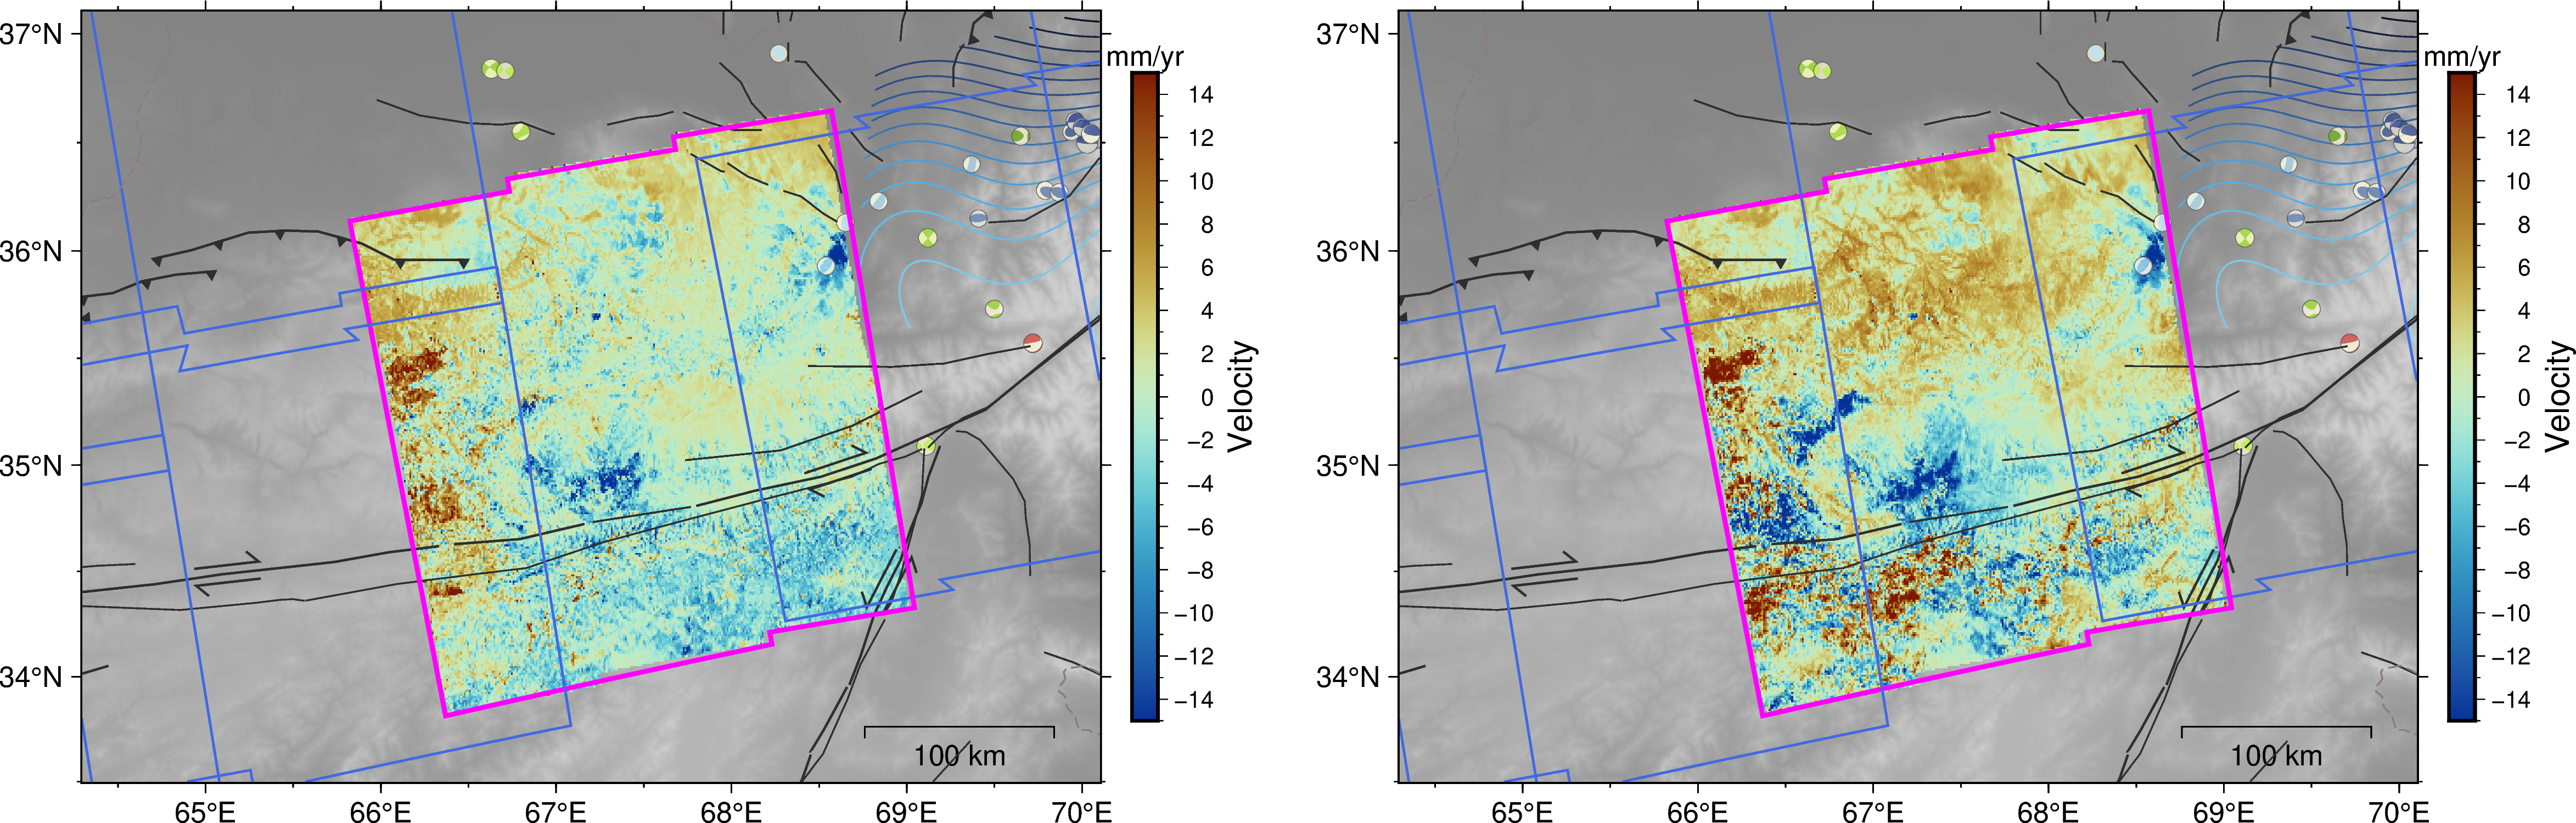

In [9]:
### GMT basemap ###
import os
dir = "/Users/rochelle/Documents/GitHub/Leeds-Research-Internship/"
os.chdir(dir)

###########################################
## Specify coords
# llcrnrlat,llcrnrlon, urcrnrlat, urcrnrlon
# are the lat/lon values of the lower left and upper right corners of the map

llcrnrlon=64.3 # lower left corner longitude 
llcrnrlat=33.5 # lower left corner latitude
urcrnrlon=70.1 # upper right corner longitude
urcrnrlat=37.1 # upper right corner latitude


proj_scale_w = 18 # specify projection scale (width)
proj_scale_unit = "c" # choose between c (cm) and i (inches)
# 17.78c = 7i

proj_subplot_scale = 5

meca_trans = 26 # meca transparency
meca_scale = "0.4c" # meca scale
trans = meca_trans
# InSAR_tif =
# InSAR_NetCDF =

# LiCSBAS 16 vel filt mskd NO RAMP    
# 13ref original: 69.7322222 35.8222222
# 13ref reunwrapped: 69.686722 35.767722
# I cant be arsed to fix the ref point issue
###########################################

centerlon = (urcrnrlon - llcrnrlon)/2 + llcrnrlon # midpoints
centerlat = (urcrnrlat - llcrnrlat)/2 + llcrnrlat
region=[llcrnrlon, urcrnrlon, llcrnrlat, urcrnrlat]


fig = pygmt.Figure()
pygmt.config(MAP_FRAME_TYPE="plain", FONT="Helvetica") # figure config (borders)

with fig.subplot(
    nrows=1, ncols=2, figsize=("%s%s" % (proj_scale_w*2, proj_scale_unit)), margins="2c"
):
     with fig.set_panel(panel=0):
                
        fig.coast(region=region,\
          projection="M?",\
          water="white", land="grey", shorelines="1/0.5p",\
          frame=["WSne", "a1f0.5"])

          # Mercator
          # a2f0.5 --> major ticks every 2 and minor ticks every 0.5

        grid = pygmt.datasets.load_earth_relief("30s", registration="gridline", region=region)

        fig.grdimage(grid=grid, cmap="bin/cpt/custom/seabluelandgrey.cpt")
        # fig.grdimage(grid=grid, cmap="geo")

        fig.coast(map_scale="g69.30/33.735+w100k", shorelines="1/0.5p", borders="1/0.6p, mistyrose4,-")

        ## plot slab2.0 here
        fig.plot(data="bin/hin_slab2_dep_02.24.18_contours.in", pen=f"0.65p", cmap="bin/cpt/abyss_slab2.0") # Hindu Kush, bounding coords 66 74 40 34
        fig.plot(data="bin/pam_slab2_dep_02.26.18_contours.in", pen=f"0.65p", cmap="bin/cpt/abyss_slab2.0") # Pamir, bounding coords 68 78 41 35

        #######################
        ## plotting vel TEST
        pygmt.makecpt(output="bin/cpt/roma_InSAR", series=[-15, 15], reverse=True, cmap="bin/cpt/GMT_supported/roma.cpt")
                    # redefine scale + inverse
                    # stored in local sesh
        nc = "144A_05476_141414.vel.geo.tif"   
        # LiCSBAS 16 vel filt mskd NO RAMP                                                     
        fig.grdimage(grid=("bin/" + nc + "?vel"), nan_transparent = True, transparency = 0, cmap="bin/cpt/roma_InSAR")

        #######################

        ## plotting HarvardCMT earthquakes by fault style 20160309 20240710
        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_thrust_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/blue.cpt",
            extensionfill="cornsilk",
            # Draw a 0.5 points thick dark gray ("gray30") solid outline via
            # the pen parameter [Default is "0.25p,black,solid"]
            pen="thinnest,gray30,solid", transparency=trans,
        )

        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_ss_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/green.cpt",
            extensionfill="cornsilk",
            pen="thinnest,gray30,solid", transparency=trans,
        )

        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_normal_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/red.cpt",
            extensionfill="cornsilk",
            pen="thinnest,gray30,solid", transparency=trans,
        )

        ## plotting faults
        # https://www.pygmt.org/dev/gallery/lines/linefronts.html
        fill_fault = "grey18"
        fig.plot(data="bin/faults/HimaTibetMap.gmt", pen=f"0.65p,"+fill_fault) # all faults
        fig.plot(data="bin/faults/gem_active_faults.gmt", pen=f"0.65p,"+fill_fault) # gem active faults
        fig.plot(data="bin/faults/normal.gmt", style="f1c/0.13c+l+b", pen=f"0.95p,"+fill_fault, fill=fill_fault) # normal
        fig.plot(data="bin/faults/thrust.gmt", style="f1c/0.13c+l+t", pen=f"0.95p,"+fill_fault, fill=fill_fault) # thrust
        fig.plot(data="bin/faults/dextral.gmt", style="f5c/1c+r+s45+o2.25c", pen=f"0.95p,"+fill_fault, fill=fill_fault) # dextral (right)
        fig.plot(data="bin/faults/sinistral.gmt", style="f5c/1c+l+s45+o2.25c", pen=f"0.95p,"+fill_fault, fill=fill_fault) # sinistral (left)


        ## plotting poly.txt

        ### Ascending ###
        fig.plot(data="bin/metadata/ascending/071A_05440_131313-poly.txt", pen=f"1p,royalblue") # 071A_05440_131313
        fig.plot(data="bin/metadata/ascending/173A_05350_131313-poly.txt", pen=f"1p,royalblue") # 173A_05350_131313
        fig.plot(data="bin/metadata/ascending/144A_05476_141414-poly.txt", pen=f"2p,magenta") # 144A_05476_141414
        fig.plot(data="bin/metadata/ascending/042A_05535_131313-poly.txt", pen=f"1p,royalblue") # 042A_05535_131313
        fig.plot(data="bin/metadata/ascending/115A_05608_131313-poly.txt", pen=f"1p, royalblue")
        # fig.plot(data="bin/metadata/ascending/013A_05597_131313-poly.txt", pen=f"1p, red")
        fig.plot(data="bin/metadata/ascending/115A_05409_131313-poly.txt", pen=f"1p, royalblue")
        fig.plot(data="bin/metadata/ascending/042A_05336_131313-poly.txt", pen=f"1p, royalblue")


        fig.coast(shorelines="1/0.5p", borders="1/0.6p, mistyrose4,-")
        # fig.plot(x=69.7322222, y=35.8222222, style="a0.55c", pen="thinnest, grey20", fill="orange")
        
        fig.colorbar(
            cmap="bin/cpt/roma_InSAR", frame=["xa2f1+lVelocity", "y+lmm/yr"],
            # offset (+o) by 0.5 cm horizontally and 0.8 cm vertically from anchor
            # point, and plotted horizontally (+h)
            position="JCR+o0.5/0c+w10c")
        ###########################################################

     with fig.set_panel(panel=1):

        fig.coast(region=region,\
          projection="M?",\
          water="white", land="grey", shorelines="1/0.5p",\
          frame=["WSne", "a1f0.5"])

          # Mercator
          # a2f0.5 --> major ticks every 2 and minor ticks every 0.5

        grid = pygmt.datasets.load_earth_relief("30s", registration="gridline", region=region)

        fig.grdimage(grid=grid, cmap="bin/cpt/custom/seabluelandgrey.cpt")
        # fig.grdimage(grid=grid, cmap="geo")

        fig.coast(map_scale="g69.30/33.735+w100k", shorelines="1/0.5p", borders="1/0.6p, mistyrose4,-")
        
        ## plot slab2.0 here
        fig.plot(data="bin/hin_slab2_dep_02.24.18_contours.in", pen=f"0.65p", cmap="bin/cpt/abyss_slab2.0") # Hindu Kush, bounding coords 66 74 40 34
        fig.plot(data="bin/pam_slab2_dep_02.26.18_contours.in", pen=f"0.65p", cmap="bin/cpt/abyss_slab2.0") # Pamir, bounding coords 68 78 41 35

        #######################
        ## plotting vel TEST
        pygmt.makecpt(output="bin/cpt/roma_InSAR", series=[-15, 15], reverse=True, cmap="bin/cpt/GMT_supported/roma.cpt")
                    # redefine scale + inverse
                    # stored in local sesh
        nc = "144A_05476_141414_singular.vel.geo.tif"   
        # LiCSBAS 16 vel filt mskd NO RAMP                                                     
        fig.grdimage(grid=("bin/" + nc + "?vel"), nan_transparent = True, transparency = 0, cmap="bin/cpt/roma_InSAR")

        #######################

        ## plotting HarvardCMT earthquakes by fault style 20160309 20240710
        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_thrust_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/blue.cpt",
            extensionfill="cornsilk",
            # Draw a 0.5 points thick dark gray ("gray30") solid outline via
            # the pen parameter [Default is "0.25p,black,solid"]
            pen="thinnest,gray30,solid", transparency=trans,
        )

        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_ss_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/green.cpt",
            extensionfill="cornsilk",
            pen="thinnest,gray30,solid", transparency=trans,
        )

        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_normal_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/red.cpt",
            extensionfill="cornsilk",
            pen="thinnest,gray30,solid", transparency=trans,
        )

        ## plotting faults
        # https://www.pygmt.org/dev/gallery/lines/linefronts.html
        fill_fault = "grey18"
        fig.plot(data="bin/faults/HimaTibetMap.gmt", pen=f"0.65p,"+fill_fault) # all faults
        fig.plot(data="bin/faults/gem_active_faults.gmt", pen=f"0.65p,"+fill_fault) # gem active faults
        fig.plot(data="bin/faults/normal.gmt", style="f1c/0.13c+l+b", pen=f"0.95p,"+fill_fault, fill=fill_fault) # normal
        fig.plot(data="bin/faults/thrust.gmt", style="f1c/0.13c+l+t", pen=f"0.95p,"+fill_fault, fill=fill_fault) # thrust
        fig.plot(data="bin/faults/dextral.gmt", style="f5c/1c+r+s45+o2.25c", pen=f"0.95p,"+fill_fault, fill=fill_fault) # dextral (right)
        fig.plot(data="bin/faults/sinistral.gmt", style="f5c/1c+l+s45+o2.25c", pen=f"0.95p,"+fill_fault, fill=fill_fault) # sinistral (left)


        ## plotting poly.txt

        ### Ascending ###
        fig.plot(data="bin/metadata/ascending/071A_05440_131313-poly.txt", pen=f"1p,royalblue") # 071A_05440_131313
        fig.plot(data="bin/metadata/ascending/173A_05350_131313-poly.txt", pen=f"1p,royalblue") # 173A_05350_131313
        fig.plot(data="bin/metadata/ascending/144A_05476_141414-poly.txt", pen=f"2p,magenta") # 144A_05476_141414
        fig.plot(data="bin/metadata/ascending/042A_05535_131313-poly.txt", pen=f"1p,royalblue") # 042A_05535_131313
        fig.plot(data="bin/metadata/ascending/115A_05608_131313-poly.txt", pen=f"1p, royalblue")
        # fig.plot(data="bin/metadata/ascending/013A_05597_131313-poly.txt", pen=f"1p, red")
        fig.plot(data="bin/metadata/ascending/115A_05409_131313-poly.txt", pen=f"1p, royalblue")
        fig.plot(data="bin/metadata/ascending/042A_05336_131313-poly.txt", pen=f"1p, royalblue")

        ## legends and stuff
        # fig.plot(x=69.7322222, y=35.8222222, style="a0.55c", pen="thinnest, grey20", fill="orange")
        fig.coast(shorelines="1/0.5p", borders="1/0.6p, mistyrose4,-")
        fig.colorbar(
            cmap="bin/cpt/roma_InSAR", frame=["xa2f1+lVelocity", "y+lmm/yr"],
            # offset (+o) by 0.5 cm horizontally and 0.8 cm vertically from anchor
            # point, and plotted horizontally (+h)
            position="JCR+o0.5/0c+w10c")
        



fig.show()
fig.savefig("generating_report_figures/output_figures/singular.png")